**Objective:** My goal for this project was to understand the "heartbeat" of New York City through its 311 service requests. I wanted to see if we could predict how long it takes the city to close out different types of complaints.

In [ ]:
# Import the drive module from google.colab
from google.colab import drive

# This command will start the mounting process
drive.mount('/content/drive')
# Import the pandas library
import pandas as pd

# IMPORTANT: Update this file path to match the location in YOUR drive
file_path = '/content/drive/MyDrive/Colab Projects/311-service-requests-from-2010-to-present.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows to confirm it worked
print("Data loaded successfully from Google Drive!")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the drive module from google.colab
from google.colab import drive

# This command will start the mounting process
drive.mount('/content/drive')
# Import the pandas library
import pandas as pd

# IMPORTANT: Update this file path to match the location in YOUR drive
file_path = '/content/drive/MyDrive/Colab Projects/311-service-requests-from-2010-to-present.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path, nrows=100000)

# Display the first 5 rows to confirm it worked
print("Data loaded successfully from Google Drive!")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-1208525259.py:13: DtypeWarning: Columns (34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, nrows=100000)


Data loaded successfully from Google Drive!


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,45050101,2019-12-01T02:04:01.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,10001.0,WEST 29 STREET,...,NaN,NaN,40.745668,-73.987719,"{'longitude': '-73.9877188309367', 'latitude':...",NaN,NaN,NaN,NaN,NaN
1,45054936,2019-12-01T01:59:41.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,178 AVENUE U,...,NaN,NaN,40.596475,-73.977721,"{'longitude': '-73.97772147626671', 'latitude'...",NaN,NaN,NaN,NaN,NaN
2,45049329,2019-12-01T01:59:08.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,807 SCHENCK AVENUE,...,NaN,NaN,40.660605,-73.883508,"{'longitude': '-73.8835082736363', 'latitude':...",NaN,NaN,NaN,NaN,NaN
3,45052046,2019-12-01T01:58:23.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11358.0,42-41 159 STREET,...,NaN,NaN,40.759994,-73.806856,"{'longitude': '-73.80685560533585', 'latitude'...",NaN,NaN,NaN,NaN,NaN
4,45054999,2019-12-01T01:58:07.000,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11426.0,88-49 237 STREET,...,NaN,NaN,40.729499,-73.729998,"{'longitude': '-73.72999847973517', 'latitude'...",NaN,NaN,NaN,NaN,NaN


In [ ]:
# Import the drive module from google.colab
from google.colab import drive

# This command will start the mounting process
drive.mount('/content/drive')
# Import the pandas library
import pandas as pd

# IMPORTANT: Update this file path to match the location in YOUR drive
file_path = '/content/drive/MyDrive/Colab Projects/311-service-requests-from-2010-to-present.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path, nrows=100000)

# Convert 'Created Date' and 'Closed Date' columns to datetime objects.
# The 'errors='coerce'' part will turn any problematic entries that can't be converted into 'NaT' (Not a Time).
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

Mounted at /content/drive


/tmp/ipython-input-3802645098.py:13: DtypeWarning: Columns (34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, nrows=100000)


In [ ]:
# Convert 'Created Date' and 'Closed Date' columns to datetime objects.
# The 'errors='coerce'' part will turn any problematic entries that can't be converted into 'NaT' (Not a Time).
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

In [ ]:
# Check the DataFrame summary again to see the changes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Unique Key                      100000 non-null  int64         
 1   Created Date                    100000 non-null  datetime64[ns]
 2   Closed Date                     81944 non-null   datetime64[ns]
 3   Agency                          100000 non-null  object        
 4   Agency Name                     100000 non-null  object        
 5   Complaint Type                  100000 non-null  object        
 6   Descriptor                      97839 non-null   object        
 7   Location Type                   71978 non-null   object        
 8   Incident Zip                    97251 non-null   float64       
 9   Incident Address                94489 non-null   object        
 10  Street Name                     94488 non-null   object  

In [ ]:
# Create a new column 'Resolution Time' by subtracting the 'Created Date' from the 'Closed Date'.
# The result will be in a 'timedelta' format (e.g., 'x days, hh:mm:ss').
df['Resolution Time'] = df['Closed Date'] - df['Created Date']

In [ ]:
# Display the first 5 rows of the key date columns to verify our calculation.
df[['Created Date', 'Closed Date', 'Resolution Time']].head()

,Created Date,Closed Date,Resolution Time
0,2019-12-01 02:04:01,NaT,NaT
1,2019-12-01 01:59:41,NaT,NaT
2,2019-12-01 01:59:08,NaT,NaT
3,2019-12-01 01:58:23,NaT,NaT
4,2019-12-01 01:58:07,NaT,NaT


**Phase 1: Cleaning the "Messy" Data**

Real-world data is never perfect. I noticed several columns had missing values. Instead of just deleting everything, I focused on columns that impact response time, like 'Created Date' and 'Closed Date'. I also had to convert these so Python could actually do math with the dates.

In [ ]:
# Drop rows where the 'Closed Date' column has a missing value (NaT).
# The 'inplace=True' argument modifies our DataFrame directly.
df.dropna(subset=['Closed Date'], inplace=True)

In [ ]:
# Display the first 5 rows again to see the result.
df[['Created Date', 'Closed Date', 'Resolution Time']].head()

,Created Date,Closed Date,Resolution Time
34,2019-12-01 01:48:45,2019-12-01 01:55:41,0 days 00:06:56
35,2019-12-01 01:48:31,2019-12-01 01:54:32,0 days 00:06:01
37,2019-12-01 01:48:20,2019-12-01 01:54:57,0 days 00:06:37
66,2019-12-01 01:36:06,2019-12-01 01:54:10,0 days 00:18:04
77,2019-12-01 01:31:56,2019-12-01 01:51:18,0 days 00:19:22


In [ ]:
# Convert the 'Resolution Time' into a numerical format (total hours).
# We get the total seconds from the timedelta and divide by 3600 (60 seconds * 60 minutes).
df['Resolution Hours'] = df['Resolution Time'].dt.total_seconds() / 3600

In [ ]:
# Display the first 5 rows to see our new numerical column.
df[['Resolution Time', 'Resolution Hours']].head()

,Resolution Time,Resolution Hours
34,0 days 00:06:56,0.115556
35,0 days 00:06:01,0.100278
37,0 days 00:06:37,0.110278
66,0 days 00:18:04,0.301111
77,0 days 00:19:22,0.322778


In [ ]:
# Get a statistical summary of our new 'Resolution Hours' column.
df['Resolution Hours'].describe()

,Resolution Hours
count,81944.000000
mean,25.298964
std,62.631266
min,-1128.000000
25%,1.675486
50%,6.747222
75%,35.440208
max,417.406667


**Phase 2: Visualizing the Trends**

I wanted to see how response times are distributed. Seeing the histogram helps show that while most requests are handled quickly, there are always a few "outliers" that take much longer.

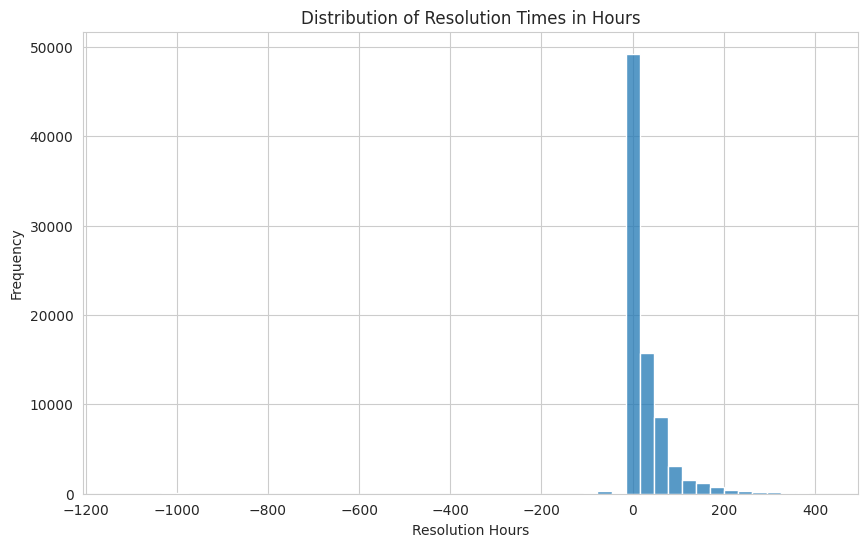

In [ ]:
# Import our visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Set a style for our plots
sns.set_style('whitegrid')

# Create a histogram of the Resolution Hours
plt.figure(figsize=(10, 6))
sns.histplot(df['Resolution Hours'], bins=50)
plt.title('Distribution of Resolution Times in Hours')
plt.xlabel('Resolution Hours')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Check how many rows we have before cleaning
print(f"Number of rows before cleaning: {len(df)}")

# Keep only the rows where 'Resolution Hours' is greater than or equal to 0
df = df[df['Resolution Hours'] >= 0]

# Check how many rows we have after cleaning
print(f"Number of rows after cleaning: {len(df)}")

Number of rows before cleaning: 81944
Number of rows after cleaning: 81259


In [ ]:
# Get the new statistical summary.
df['Resolution Hours'].describe()

,Resolution Hours
count,81259.000000
mean,27.832860
std,46.801521
min,0.000000
25%,1.746944
50%,6.916667
75%,35.937917
max,417.406667


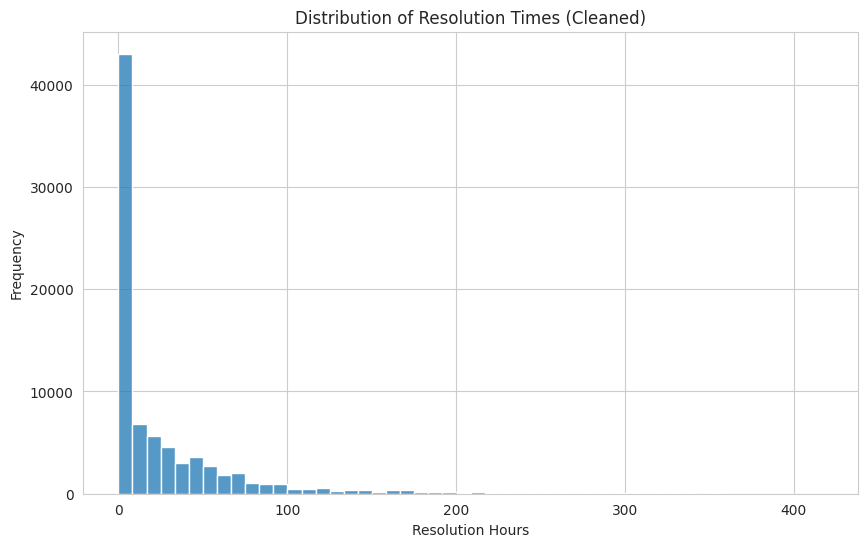

In [ ]:
# Re-create the histogram to see the new distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Resolution Hours'], bins=50)
plt.title('Distribution of Resolution Times (Cleaned)')
plt.xlabel('Resolution Hours')
plt.ylabel('Frequency')
plt.show()

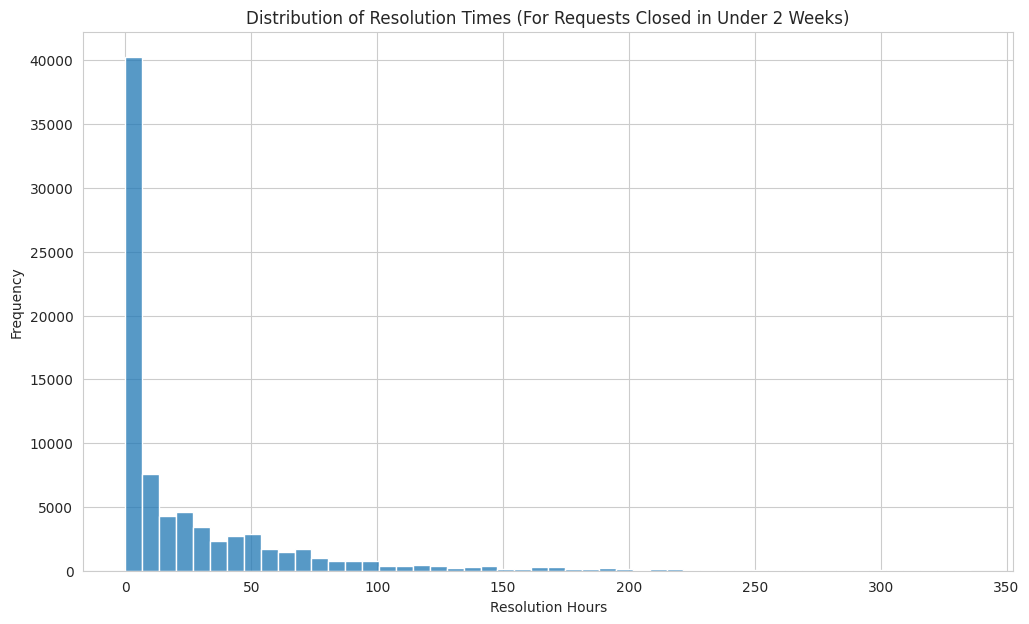

In [ ]:
# Create a histogram for requests resolved in under 2 weeks (14 days * 24 hours = 336 hours)
plt.figure(figsize=(12, 7))
sns.histplot(df[df['Resolution Hours'] < 336]['Resolution Hours'], bins=50)
plt.title('Distribution of Resolution Times (For Requests Closed in Under 2 Weeks)')
plt.xlabel('Resolution Hours')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# First, let's find the top 10 most common complaint types in our dataset
top_10_complaints = df['Complaint Type'].value_counts().head(10)
print("Top 10 Most Common Complaint Types:")
print(top_10_complaints)

# Now, let's calculate the average resolution time for each of these top 10 types.
# We first filter our DataFrame to only include these top complaints.
df_top_10 = df[df['Complaint Type'].isin(top_10_complaints.index)]

# Then, we group by complaint type and calculate the mean resolution hours.
avg_hours_by_complaint = df_top_10.groupby('Complaint Type')['Resolution Hours'].mean().sort_values()

print("\nAverage Resolution Hours for Top 10 Complaint Types:")
print(avg_hours_by_complaint)

Top 10 Most Common Complaint Types:
Complaint Type
HEAT/HOT WATER                       17204
Noise - Residential                  11158
Illegal Parking                       9638
Blocked Driveway                      7423
Missed Collection (All Materials)     2260
Water System                          2203
Street Condition                      2139
General Construction/Plumbing         1867
Traffic Signal Condition              1847
Noise - Commercial                    1802
Name: count, dtype: int64

Average Resolution Hours for Top 10 Complaint Types:
Complaint Type
Noise - Commercial                    3.466067
Illegal Parking                       5.796160
Noise - Residential                   6.075922
Blocked Driveway                      7.489546
Traffic Signal Condition             11.706786
Water System                         17.270548
General Construction/Plumbing        29.647615
Street Condition                     43.464467
HEAT/HOT WATER                       46.890508
M

**Phase 3: Comparing Categories**

I wanted to see which types of complaints were the most common. Using a colorful bar chart makes it much easier to spot the "top offenders" at a glance.

/tmp/ipython-input-2919113917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hours_by_complaint.values, y=avg_hours_by_complaint.index, palette='viridis')


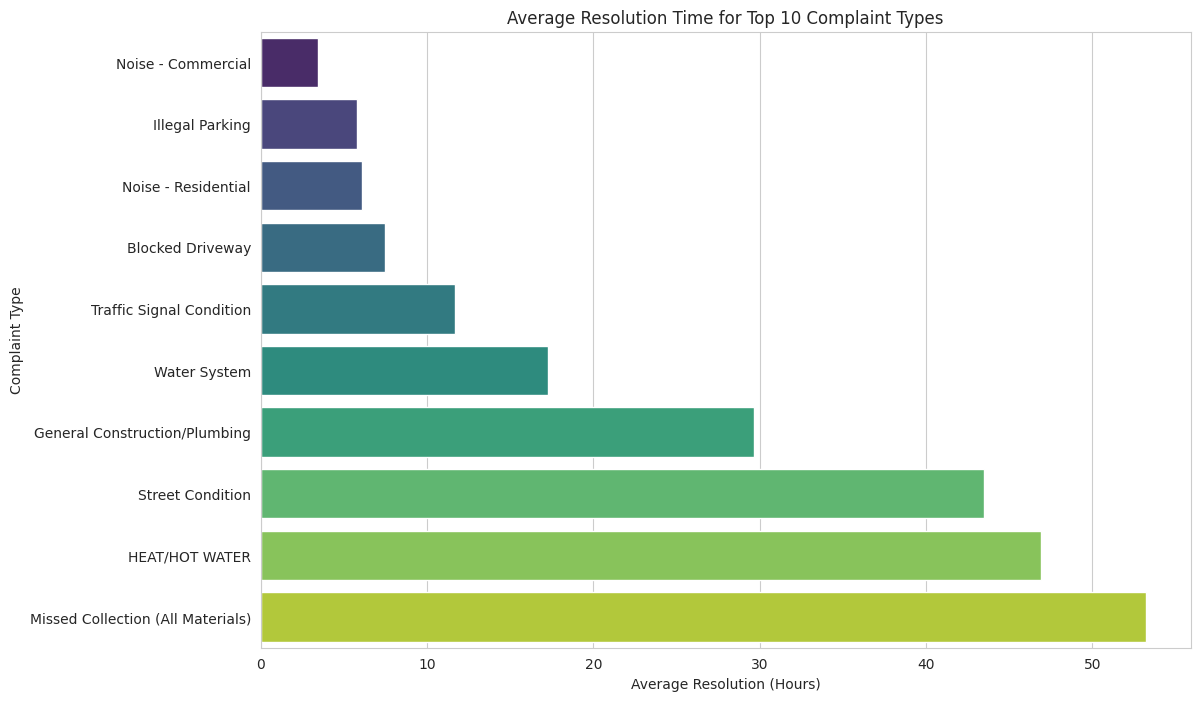

In [ ]:
# Create a bar plot to visualize the average resolution time by complaint type
plt.figure(figsize=(12, 8))
sns.barplot(x=avg_hours_by_complaint.values, y=avg_hours_by_complaint.index, palette='viridis')
plt.title('Average Resolution Time for Top 10 Complaint Types')
plt.xlabel('Average Resolution (Hours)')
plt.ylabel('Complaint Type')
plt.show()

In [ ]:
# Group the data by 'Borough' and calculate the mean resolution hours for each.
avg_hours_by_borough = df.groupby('Borough')['Resolution Hours'].mean().sort_values()

print("Average Resolution Hours by Borough:")
print(avg_hours_by_borough)

Average Resolution Hours by Borough:
Borough
QUEENS           24.105486
BROOKLYN         25.709570
MANHATTAN        27.007440
STATEN ISLAND    30.163049
BRONX            35.724191
Unspecified      47.058969
Name: Resolution Hours, dtype: float64


/tmp/ipython-input-976249817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hours_by_borough.index, y=avg_hours_by_borough.values, palette='plasma')


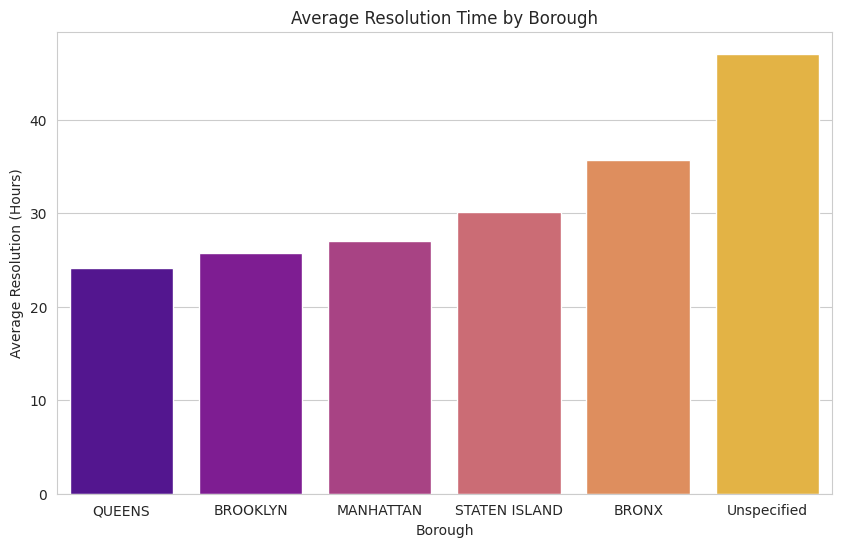

In [ ]:
# Create a bar plot to visualize the average resolution time by borough
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_hours_by_borough.index, y=avg_hours_by_borough.values, palette='plasma')
plt.title('Average Resolution Time by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Resolution (Hours)')
plt.show()

In [ ]:
# Select our features (the columns we use to predict) and the target (what we want to predict).
features = ['Borough', 'Complaint Type']
target = 'Resolution Hours'

# Create a new DataFrame with just our features and target.
df_model = df[features + [target]].copy()

# Use one-hot encoding to convert the categorical features into numbers.
df_encoded = pd.get_dummies(df_model, columns=features, drop_first=True)

# Display the first 5 rows of our newly encoded data.
df_encoded.head()

,Resolution Hours,Borough_BROOKLYN,Borough_MANHATTAN,Borough_QUEENS,Borough_STATEN ISLAND,Borough_Unspecified,Complaint Type_Abandoned Vehicle,Complaint Type_Air Quality,Complaint Type_Animal in a Park,Complaint Type_Animal-Abuse,...,Complaint Type_UNSANITARY CONDITION,Complaint Type_Unsanitary Animal Pvt Property,Complaint Type_Unsanitary Pigeon Condition,Complaint Type_Urinating in Public,Complaint Type_Vending,Complaint Type_Violation of Park Rules,Complaint Type_WATER LEAK,Complaint Type_Water Conservation,Complaint Type_Water Quality,Complaint Type_Water System
34,0.115556,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
35,0.100278,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
37,0.110278,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
66,0.301111,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
77,0.322778,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Import the function we need from scikit-learn
from sklearn.model_selection import train_test_split

# Define our 'X' (the features/predictors) and 'y' (the target).
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Split the data: 80% for training, 20% for testing.
# The 'random_state' ensures we get the same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of our new datasets to confirm the split.
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (65007, 117)
Shape of X_test: (16252, 117)
Shape of y_train: (65007,)
Shape of y_test: (16252,)


In [ ]:
# Import the Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Create an instance of the model
model = LinearRegression()

# Train the model using our training data
# The .fit() command is the "learning" step
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [ ]:
# Use the trained model to make predictions on the test data
predictions = model.predict(X_test)

print("Predictions made successfully!")

Predictions made successfully!


In [ ]:
# Import the metrics we need from scikit-learn
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate the Mean Absolute Error
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f} hours")

# Calculate the R-squared value
r2 = r2_score(y_test, predictions)
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 19.08 hours
R-squared (R²): 0.41


**Final Thoughts:**

This project taught me that data cleaning is easily 80% of the work. If I were to take this further, I’d love to overlay weather data to see if snowstorms or heavy rain significantly slow down the city's response times.

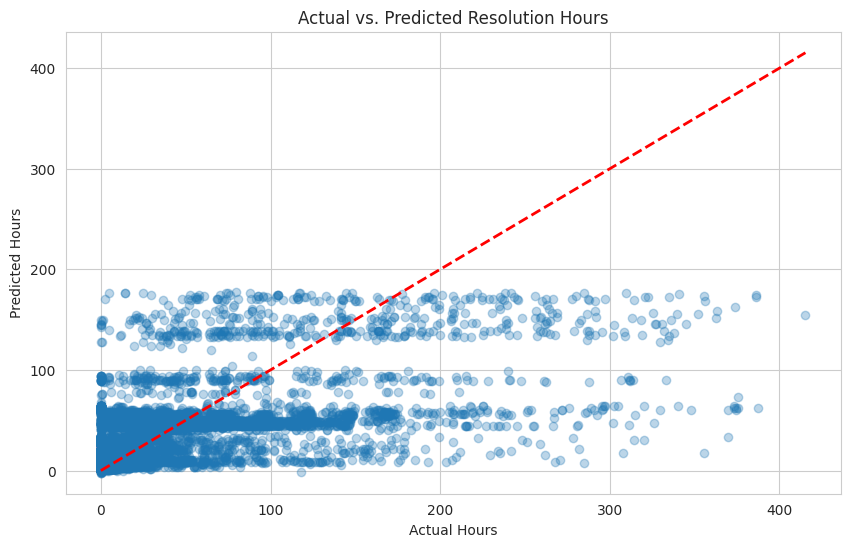

In [ ]:
# Create a scatter plot to compare actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], '--', color='red', linewidth=2) # The perfect prediction line
plt.title('Actual vs. Predicted Resolution Hours')
plt.xlabel('Actual Hours')
plt.ylabel('Predicted Hours')
plt.show()